# Dual-Stream Audio Deepfake Detection (CNN-GRU)

This notebook trains the audio deepfake detector using:
- **Model**: `AudioDualStreamDetector` (ResNet18 Mel + ResNet18 LFCC + Attention + BiGRU)
- **Dataset**: `AudioDataset` (16 kHz, 4.0 s, dual-stream features)
- **Loss**: CrossEntropyLoss (label_smoothing=0.1)
- **Label Mapping**: Fake = 0, Real = 1

**Note:** The results shown in this notebook may differ from those reported in the final report, as no fixed random seed was set during training. Variations in initialization, data shuffling, and GPU non-determinism can lead to slightly different outcomes across runs.

In [1]:
import sys, os, warnings
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader

warnings.filterwarnings('ignore')
sys.path.insert(0, os.path.abspath('..'))

from configs import AudioTrainConfig
from models.audio_detector import AudioDualStreamDetector
from data_loaders.audio_dataset import AudioDataset
from engine.trainer import train_one_epoch, EarlyStopping, unpack_dual_stream
from engine.evaluator import evaluate, compute_metrics
from common.checkpoint import save_best_model
from common.visualization import (
    plot_training_history, plot_roc_curve,
    plot_precision_recall_curve, plot_confusion_matrix
)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')

torch.backends.cudnn.benchmark = True

Using device: cuda
GPU: NVIDIA RTX 4000 Ada Generation


## 1. Configuration

In [2]:
cfg = AudioTrainConfig()
print(cfg)

AudioTrainConfig(epochs=30, batch_size=32, learning_rate=5e-05, weight_decay=0.0001, label_smoothing=0.1, scheduler='reduce_on_plateau', scheduler_factor=0.5, scheduler_patience=5, early_stopping_patience=5, early_stopping_mode='max', num_workers=4, target_sr=16000, target_duration=4.0, n_mels=128, n_lfcc=128, n_fft=1024, hop_length=512, perf=PerformanceConfig(num_workers=4, pin_memory=True, persistent_workers=False, prefetch_factor=2, cudnn_benchmark=True, use_amp=True, compile_model=False, compile_backend='inductor'))


## 2. Datasets & DataLoaders

In [3]:
DATA_ROOT = '../data/audio'
perf = cfg.perf

train_dataset = AudioDataset(os.path.join(DATA_ROOT, 'train'), target_sr=cfg.target_sr,
                             target_duration=cfg.target_duration, is_train=True)
val_dataset   = AudioDataset(os.path.join(DATA_ROOT, 'val'),   target_sr=cfg.target_sr,
                             target_duration=cfg.target_duration, is_train=False)
test_dataset  = AudioDataset(os.path.join(DATA_ROOT, 'test'),  target_sr=cfg.target_sr,
                             target_duration=cfg.target_duration, is_train=False)

loader_kwargs = dict(
    num_workers=perf.num_workers,
    pin_memory=perf.pin_memory,
    persistent_workers=perf.persistent_workers and perf.num_workers > 0,
    prefetch_factor=perf.prefetch_factor if perf.num_workers > 0 else None,
)

train_loader = DataLoader(train_dataset, batch_size=cfg.batch_size, shuffle=True,  **loader_kwargs)
val_loader   = DataLoader(val_dataset,   batch_size=cfg.batch_size, shuffle=False, **loader_kwargs)
test_loader  = DataLoader(test_dataset,  batch_size=cfg.batch_size, shuffle=False, **loader_kwargs)

print(f'Train batches: {len(train_loader)}, Val: {len(val_loader)}, Test: {len(test_loader)}')
print(f'DataLoader: num_workers={perf.num_workers}, prefetch_factor={perf.prefetch_factor}, persistent_workers={perf.persistent_workers}')

Loaded 7700 audio files from ../data/audio\train
  Fake (Class 0): 3850, Real (Class 1): 3850
Loaded 1650 audio files from ../data/audio\val
  Fake (Class 0): 825, Real (Class 1): 825
Loaded 1650 audio files from ../data/audio\test
  Fake (Class 0): 825, Real (Class 1): 825
Train batches: 241, Val: 52, Test: 52
DataLoader: num_workers=4, prefetch_factor=2, persistent_workers=False


## 3. Model, Optimizer, Scheduler

In [4]:
model = AudioDualStreamDetector().to(device)

if perf.compile_model:
    model = torch.compile(model, backend=perf.compile_backend)
    print(f'Model compiled with backend={perf.compile_backend}')

criterion = nn.CrossEntropyLoss(label_smoothing=cfg.label_smoothing)
optimizer = optim.Adam(model.parameters(), lr=cfg.learning_rate, weight_decay=cfg.weight_decay)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min',
    factor=cfg.scheduler_factor,
    patience=cfg.scheduler_patience,
)

scaler = torch.amp.GradScaler('cuda', enabled=perf.use_amp)
print(f'AMP enabled: {perf.use_amp}')

print(f'Optimizer: Adam (lr={cfg.learning_rate}, wd={cfg.weight_decay})')
print(f'Scheduler: ReduceLROnPlateau (factor={cfg.scheduler_factor}, patience={cfg.scheduler_patience})')

AMP enabled: True
Optimizer: Adam (lr=5e-05, wd=0.0001)
Scheduler: ReduceLROnPlateau (factor=0.5, patience=5)


## 4. Training Loop

In [5]:
history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': [], 'val_auc': []}
early_stop = EarlyStopping(patience=cfg.early_stopping_patience, mode=cfg.early_stopping_mode)
best_val_auc = 0.0

for epoch in range(cfg.epochs):
    print(f'\nEpoch {epoch+1}/{cfg.epochs}')

    train_loss, train_acc = train_one_epoch(
        model, train_loader, criterion, optimizer, device,
        unpack_fn=unpack_dual_stream,
        scaler=scaler, use_amp=perf.use_amp,
    )

    val_results = evaluate(
        model, val_loader, criterion, device,
        unpack_fn=unpack_dual_stream,
        use_amp=perf.use_amp,
    )

    scheduler.step(val_results['val_loss'])

    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_results['val_loss'])
    history['val_acc'].append(val_results['accuracy'])
    history['val_auc'].append(val_results['roc_auc'])

    current_lr = optimizer.param_groups[0]['lr']
    print(f"  Train Loss: {train_loss:.4f} | Acc: {train_acc*100:.2f}%")
    print(f"  Val   Loss: {val_results['val_loss']:.4f} | Acc: {val_results['accuracy']*100:.2f}% | AUC: {val_results['roc_auc']:.4f}")
    print(f"  LR: {current_lr:.2e}")

    if val_results['roc_auc'] > best_val_auc:
        best_val_auc = val_results['roc_auc']
        save_best_model(model, '../saved_models/best_audio_cnn_gru.pth', epoch, val_results)

    if early_stop(val_results['roc_auc']):
        break

print(f'\nBest Val AUC: {best_val_auc:.4f}')


Epoch 1/30


  Train Loss: 0.5997 | Acc: 72.82%
  Val   Loss: 0.5624 | Acc: 76.91% | AUC: 0.8501
  LR: 5.00e-05
Best model saved to ../saved_models/best_audio_cnn_gru.pth

Epoch 2/30


  Train Loss: 0.5171 | Acc: 78.70%
  Val   Loss: 0.4721 | Acc: 81.76% | AUC: 0.9097
  LR: 5.00e-05
Best model saved to ../saved_models/best_audio_cnn_gru.pth

Epoch 3/30


  Train Loss: 0.4696 | Acc: 82.60%
  Val   Loss: 0.4212 | Acc: 85.45% | AUC: 0.9340
  LR: 5.00e-05
Best model saved to ../saved_models/best_audio_cnn_gru.pth

Epoch 4/30


  Train Loss: 0.4187 | Acc: 86.44%
  Val   Loss: 0.4227 | Acc: 85.94% | AUC: 0.9524
  LR: 5.00e-05
Best model saved to ../saved_models/best_audio_cnn_gru.pth

Epoch 5/30


...

  Train Loss: 0.2591 | Acc: 97.26%
  Val   Loss: 0.3217 | Acc: 92.79% | AUC: 0.9860
  LR: 5.00e-05
EarlyStopping counter: 1/5

Epoch 15/30


  Train Loss: 0.2465 | Acc: 97.96%
  Val   Loss: 0.2803 | Acc: 95.09% | AUC: 0.9922
  LR: 5.00e-05
EarlyStopping counter: 2/5

Epoch 16/30


  Train Loss: 0.2424 | Acc: 98.23%
  Val   Loss: 0.2806 | Acc: 95.09% | AUC: 0.9873
  LR: 5.00e-05
EarlyStopping counter: 3/5

Epoch 17/30


  Train Loss: 0.2446 | Acc: 98.06%
  Val   Loss: 0.2957 | Acc: 94.73% | AUC: 0.9910
  LR: 5.00e-05
EarlyStopping counter: 4/5

Epoch 18/30


  Train Loss: 0.2460 | Acc: 97.96%
  Val   Loss: 0.3877 | Acc: 89.58% | AUC: 0.9895
  LR: 5.00e-05
EarlyStopping counter: 5/5
Early stopping triggered!

Best Val AUC: 0.9932


## 5. Test Evaluation

In [6]:
from common.checkpoint import load_model_weights_only

load_model_weights_only(model, '../saved_models/best_audio_cnn_gru.pth', device=device)

test_results = evaluate(
    model, test_loader, criterion, device,
    unpack_fn=unpack_dual_stream,
    use_amp=perf.use_amp,
)

labels_fake = (test_results['all_labels'] == 0).astype(int)

metrics = compute_metrics(
    test_results['all_labels'], test_results['all_preds'], test_results['all_probs'],
)

print(f"Test Accuracy:  {metrics['accuracy']*100:.2f}%")
print(f"Test Precision: {metrics['precision']:.4f}")
print(f"Test Recall:    {metrics['recall']:.4f}")
print(f"Test F1:        {metrics['f1']:.4f}")
print(f"Test AUC-ROC:   {test_results['roc_auc']:.4f}")
print(f"Test AUC-PR:    {test_results['pr_auc']:.4f}")

Model weights loaded from ../saved_models/best_audio_cnn_gru.pth


Test Accuracy:  95.09%
Test Precision: 0.9882
Test Recall:    0.9127
Test F1:        0.9490
Test AUC-ROC:   0.9936
Test AUC-PR:    0.9942


## 6. Visualization

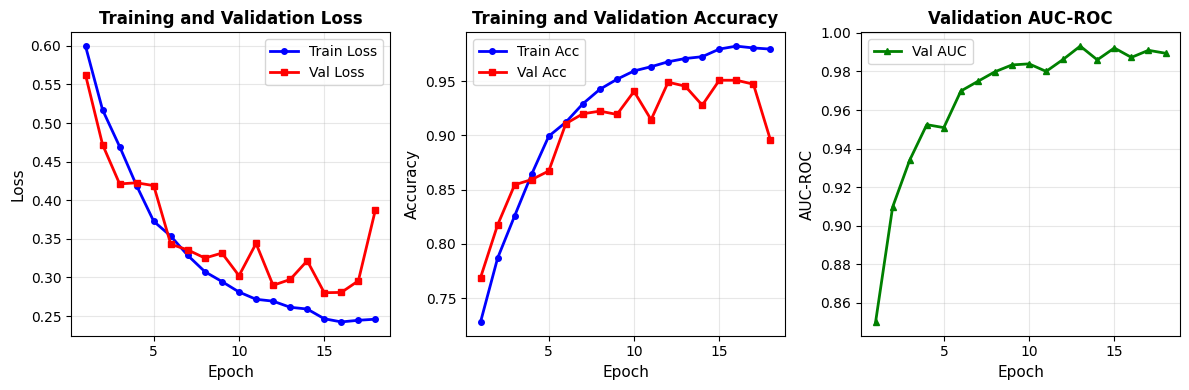

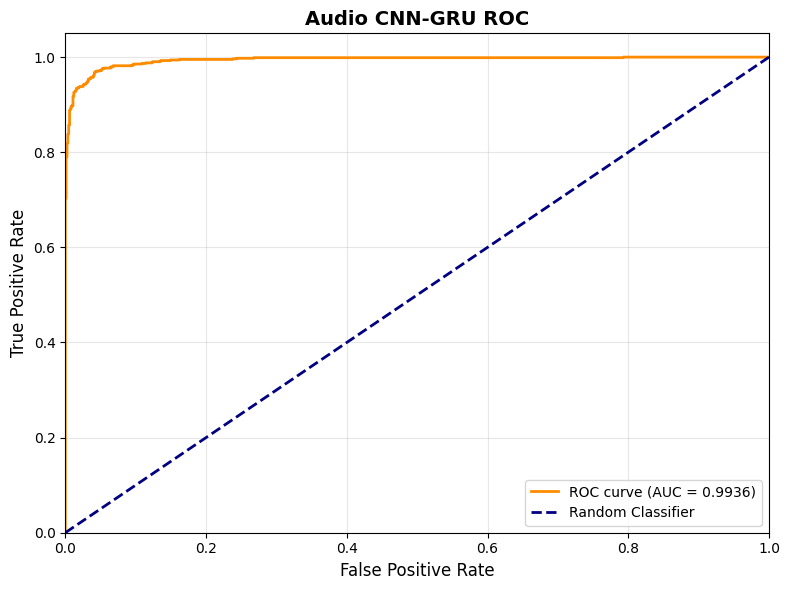

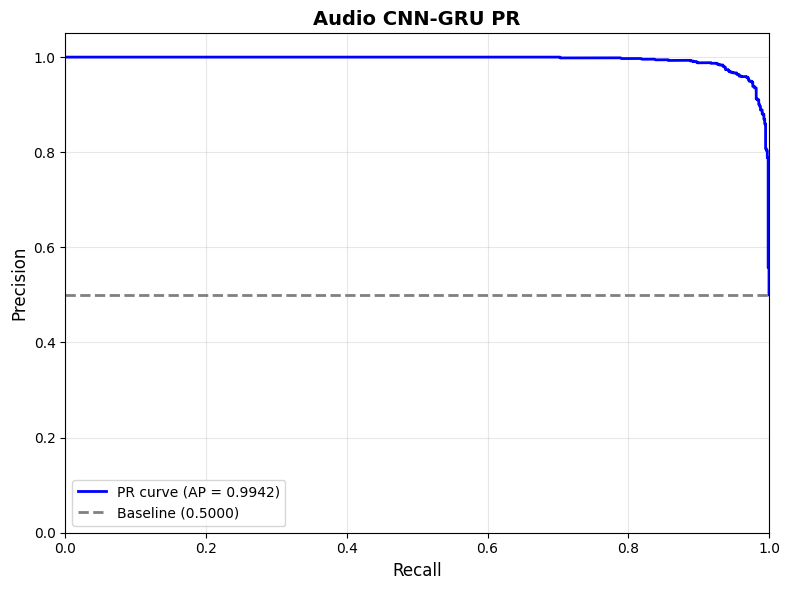

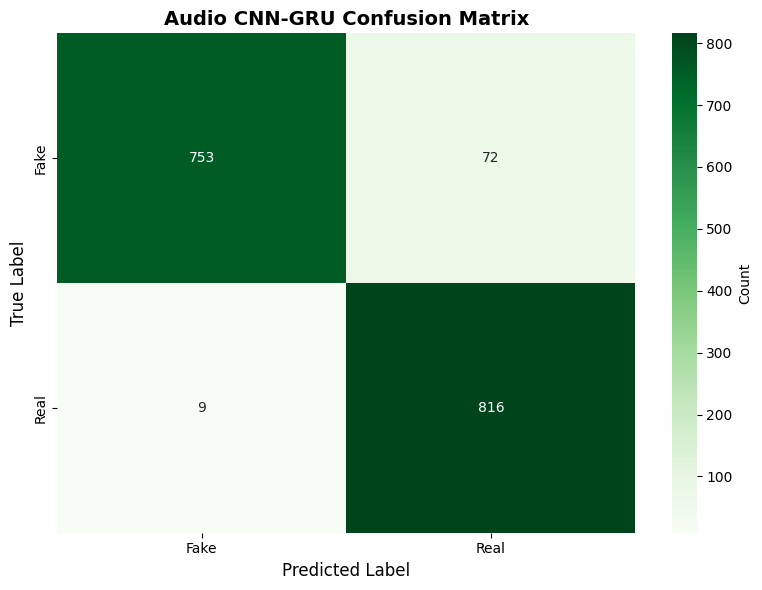

In [9]:
plot_training_history(
    history['train_loss'], history['val_loss'],
    history['train_acc'], history['val_acc'], history['val_auc'],
    save_path='../results/audio_training_curves.png',
)

plot_roc_curve(labels_fake, test_results['all_probs'],
               title='Audio CNN-GRU ROC', save_path='../results/audio_roc.png')
plot_precision_recall_curve(labels_fake, test_results['all_probs'],
                            title='Audio CNN-GRU PR', save_path='../results/audio_pr.png')
plot_confusion_matrix(test_results['all_labels'], test_results['all_preds'],
                      title='Audio CNN-GRU Confusion Matrix',
                      save_path='../results/audio_cm.png');